In [6]:
import zipfile
import pandas as pd
import os

# Define the path to the zip file
zip_file_path = '/India Agriculture Crop Production.csv.zip'

# Define the directory where the CSV will be extracted
extract_dir = '/content/'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Assuming the CSV file inside the zip is named 'India Agriculture Crop Production.csv'
# We need to find the actual name after extraction
# Let's list files in the extract_dir to confirm
extracted_files = os.listdir(extract_dir)
csv_file_name = None
for f in extracted_files:
    if f.endswith('.csv') and 'India Agriculture Crop Production' in f:
        csv_file_name = f
        break

if csv_file_name:
    csv_file_path = os.path.join(extract_dir, csv_file_name)
    # Load the dataset
    df = pd.read_csv(csv_file_path)

    # Filter for 'Rice' crop
    rice_df = df[df['Crop'] == 'Rice']

    # Group by state and sum the production, handling missing values by filling with 0 or dropping
    # For summing production, it's safer to fill NaN with 0 or drop rows with NaN production if appropriate
    rice_production_by_state = rice_df.groupby('State')['Production'].sum().reset_index()

    # Find the state with the maximum rice production
    most_producing_state = rice_production_by_state.loc[rice_production_by_state['Production'].idxmax()]

    print(f"The state that produces the most rice crop is: {most_producing_state['State']} with a total production of {most_producing_state['Production']} units.")
else:
    print(f"Could not find a CSV file matching 'India Agriculture Crop Production' in {extract_dir} after extraction.")


The state that produces the most rice crop is: West Bengal with a total production of 338984869.0 units.


/tmp/ipykernel_1624/1496074563.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Production', y='District', data=west_bengal_rice_by_district, palette='viridis')


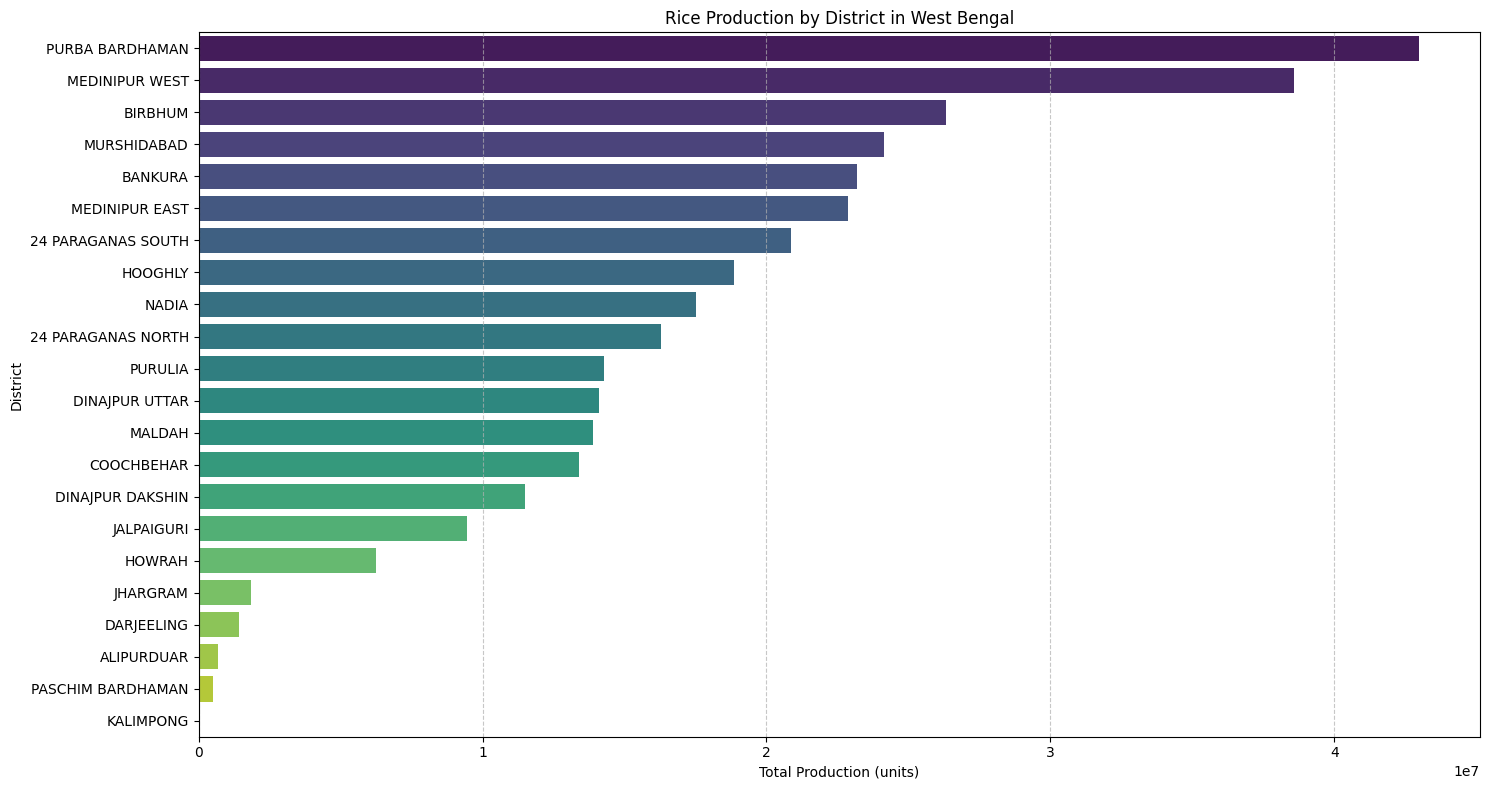

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for West Bengal and Rice crop
west_bengal_rice_df = df[(df['State'] == 'West Bengal') & (df['Crop'] == 'Rice')]

# Group by district and sum the production
west_bengal_rice_by_district = west_bengal_rice_df.groupby('District')['Production'].sum().reset_index()

# Sort for better visualization
west_bengal_rice_by_district = west_bengal_rice_by_district.sort_values(by='Production', ascending=False)

# Create the bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x='Production', y='District', data=west_bengal_rice_by_district, palette='viridis')
plt.title('Rice Production by District in West Bengal')
plt.xlabel('Total Production (units)')
plt.ylabel('District')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


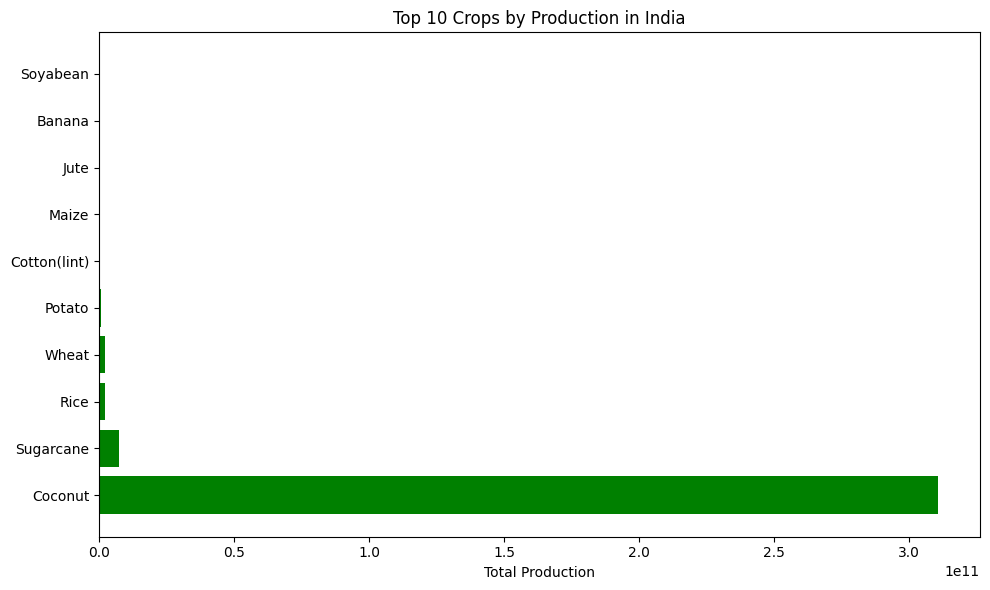

In [8]:
top_crops = df.groupby('Crop')['Production'].sum().nlargest(10).reset_index()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_crops['Crop'], top_crops['Production'], color='green')
plt.title('Top 10 Crops by Production in India')
plt.xlabel('Total Production')
plt.tight_layout()
plt.savefig('top_crops.png')
plt.show()

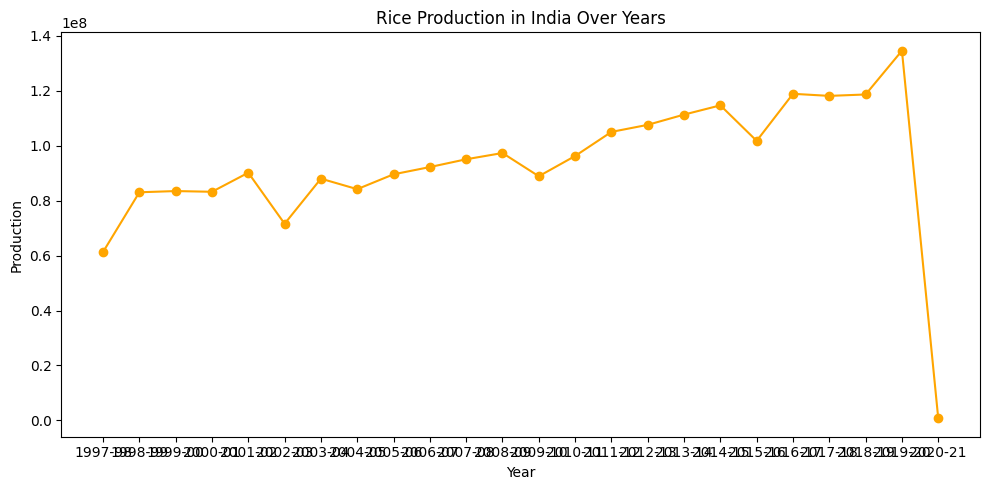

In [10]:
rice_trend = rice_df.groupby('Year')['Production'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(rice_trend['Year'], rice_trend['Production'], marker='o', color='orange')
plt.title('Rice Production in India Over Years')
plt.xlabel('Year')
plt.ylabel('Production')
plt.tight_layout()
plt.savefig('rice_trend.png')
plt.show()